In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

pd.set_option('display.max_columns', 150)


In [2]:
df = pd.read_csv('/home/carlos/baseball_pitch_classifier/data/raw/pitch_data_2023.csv')
display(df.head())
print(df.shape)

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,spin_dir,spin_rate_deprecated,break_angle_deprecated,break_length_deprecated,zone,des,game_type,stand,p_throws,home_team,away_team,type,hit_location,bb_type,balls,strikes,game_year,pfx_x,pfx_z,plate_x,plate_z,on_3b,on_2b,on_1b,outs_when_up,inning,inning_topbot,hc_x,hc_y,tfs_deprecated,tfs_zulu_deprecated,umpire,sv_id,vx0,vy0,vz0,ax,ay,az,sz_top,sz_bot,hit_distance_sc,launch_speed,launch_angle,effective_speed,release_spin_rate,release_extension,game_pk,fielder_2,fielder_3,fielder_4,fielder_5,fielder_6,fielder_7,fielder_8,fielder_9,release_pos_y,estimated_ba_using_speedangle,estimated_woba_using_speedangle,woba_value,woba_denom,babip_value,iso_value,launch_speed_angle,at_bat_number,pitch_number,pitch_name,home_score,away_score,bat_score,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length,estimated_slg_using_speedangle,delta_pitcher_run_exp,hyper_speed,home_score_diff,bat_score_diff,home_win_exp,bat_win_exp,age_pit_legacy,age_bat_legacy,age_pit,age_bat,n_thruorder_pitcher,n_priorpa_thisgame_player_at_bat,pitcher_days_since_prev_game,batter_days_since_prev_game,pitcher_days_until_next_game,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,FF,2023-08-23,94.2,-1.98,5.78,"Ohtani, Shohei",687952,660271,NaN,foul,NaN,NaN,NaN,NaN,5.0,Foul,R,R,R,LAA,CIN,S,NaN,NaN,2,2,2023,-0.61,1.05,-0.105888,2.143918,NaN,NaN,668715.0,1,2,Top,NaN,NaN,NaN,NaN,NaN,NaN,6.271016,-136.825617,-6.071223,-9.087423,33.047214,-17.755643,3.360000,1.550000,211.0,73.8,32.0,94.6,2289.0,6.8,716890,681351,592273,650859,500871,623205,545341,666160,592669,53.65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,5,4-Seam Fastball,2,0,0,2,0,2,0,2,Standard,Standard,204.0,0.000,0.000,66.5,6.4,NaN,0.000,88.0,2,-2,0.700,0.300,28,23,29,24,1,0,14.0,1.0,NaN,0.0,1.54,0.61,0.61,36.7,-4.202834,12.458157,45.852356,33.442154,14.481477
1,ST,2023-08-23,76.1,-2.01,5.74,"Ohtani, Shohei",687952,660271,NaN,swinging_strike,NaN,NaN,NaN,NaN,14.0,Swinging Strike,R,R,R,LAA,CIN,S,NaN,NaN,2,1,2023,1.20,0.09,0.887469,2.386156,NaN,NaN,668715.0,1,2,Top,NaN,NaN,NaN,NaN,NaN,NaN,3.929574,-110.687894,0.023599,8.873675,24.053258,-31.752241,3.360000,1.550000,NaN,NaN,NaN,75.7,1217.0,6.5,716890,681351,592273,650859,500871,623205,545341,666160,592669,54.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,4,Sweeper,2,0,0,2,0,2,0,2,Standard,Standard,65.0,0.009,-0.054,73.1,8.0,NaN,0.054,NaN,2,-2,0.691,0.309,28,23,29,24,1,0,14.0,1.0,NaN,0.0,3.93,-1.20,-1.20,33.4,24.483839,-18.860531,31.139489,46.639877,45.844232
2,ST,2023-08-23,77.2,-2.05,5.60,"Ohtani, Shohei",687952,660271,NaN,swinging_strike,NaN,NaN,NaN,NaN,6.0,Swinging Strike,R,R,R,LAA,CIN,S,NaN,NaN,2,0,2023,0.75,0.55,0.798227,2.114719,NaN,NaN,668715.0,1,2,Top,NaN,NaN,NaN,NaN,NaN,NaN,4.735244,-112.322517,-1.350023,5.239909,23.744398,-27.537504,3.360000,1.550000,NaN,NaN,NaN,77.2,2188.0,6.7,716890,681351,592273,650859,500871,623205,545341,666160,592669,53.82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,3,Sweeper,2,0,0,2,0,2,0,2,Standard,Standard,69.0,0.008,-0.061,69.9,8.6,NaN,0.061,NaN,2,-2,0.683,0.317,28,23,29,24,1,0,14.0,1.0,NaN,0.0,3.33,-0.75,-0.75,34.0,28.246374,-30.924819,32.979893,44.869684,54.220186
3,FS,2023-08-23,90.1,-1.94,5.69,"Ohtani, Shohei",687952,660271,NaN,ball,NaN,NaN,NaN,NaN,14.0,Ball,R,R,R,LAA,CIN,B,NaN,NaN,1,0,2023,-1.41,0.58,0.588611,1.010921,NaN,NaN,668715.0,1,2,Top,NaN,NaN,NaN,NaN,NaN,NaN,9.369304,-130.719148,-6.852454,-18.235704,29.715268,-24.197503,3.393171,1.528939,NaN,NaN,NaN,90.5,1000.0,6.9,716890,681351,592273,650859,500871,623205,545341,666160,592669,53.64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11,2,Split-Finger,2,0,0,2,0,2,0,2,Standard,Standard,317.0,-0.008,0.054,NaN,NaN,NaN,-0.054,

(13672, 118)


In [3]:
with open('/home/carlos/baseball_pitch_classifier/configs/data.yaml', 'r') as f:
    config = yaml.safe_load(f)

excluded = config['filtering']['exclude_pitch_types']
threshold = config['filtering']['min_pitch_count']

df = df.dropna(subset=['pitch_type'])
df = df[~df['pitch_type'].isin(excluded)]
pitch_counts = df['pitch_type'].value_counts()
df = df[df['pitch_type'].isin(pitch_counts[pitch_counts >= threshold].index)]


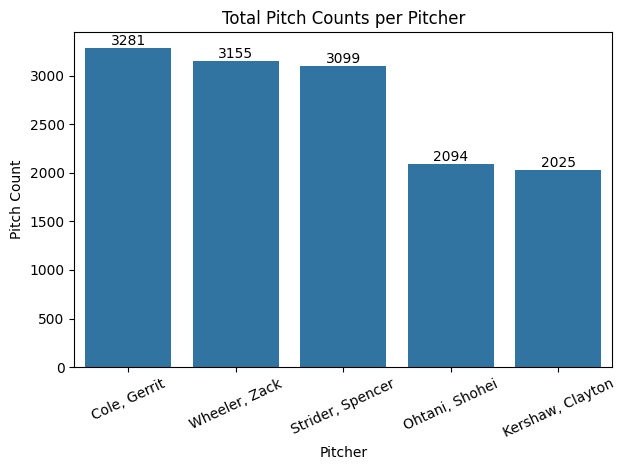

In [4]:
sns.countplot(data=df, x='player_name', order=df['player_name'].value_counts().index)

ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title('Total Pitch Counts per Pitcher')
plt.xlabel('Pitcher')
plt.ylabel('Pitch Count')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


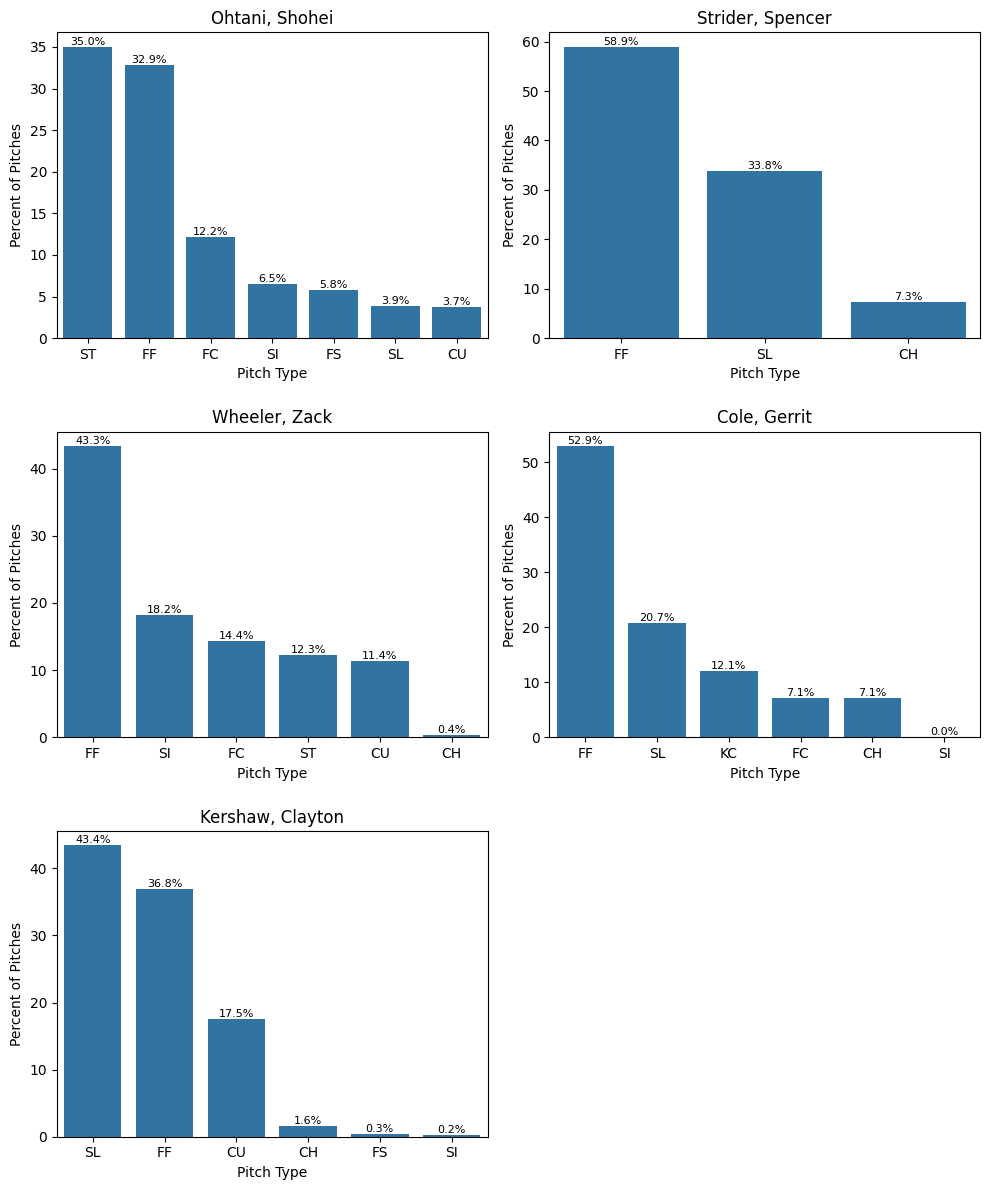

In [5]:
pitchers = df['player_name'].unique()
n_cols = 2
n_rows = -(-len(pitchers) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows * 4), sharey=False)
axes = axes.flatten()

for ax, pitcher in zip(axes, pitchers):
    pitcher_df = df[df['player_name'] == pitcher]
    order = pitcher_df['pitch_type'].value_counts().index
    sns.countplot(data=pitcher_df, x='pitch_type', ax=ax, stat='percent', order=order)
    ax.set_title(pitcher)
    ax.set_xlabel('Pitch Type')
    ax.set_ylabel('Percent of Pitches')

    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)


for ax in axes[len(pitchers):]:
    ax.set_visible(False)

plt.tight_layout(h_pad=2)
plt.show()


| Abbreviation | Pitch Name |
|---|---|
| FF | 4-Seam Fastball |
| SI | Sinker |
| FC | Cutter |
| SL | Slider |
| ST | Sweeper |
| CU | Curveball |
| KC | Knuckle Curve |
| CH | Changeup |
| FS | Splitter |
| FA | Fastball (generic) |

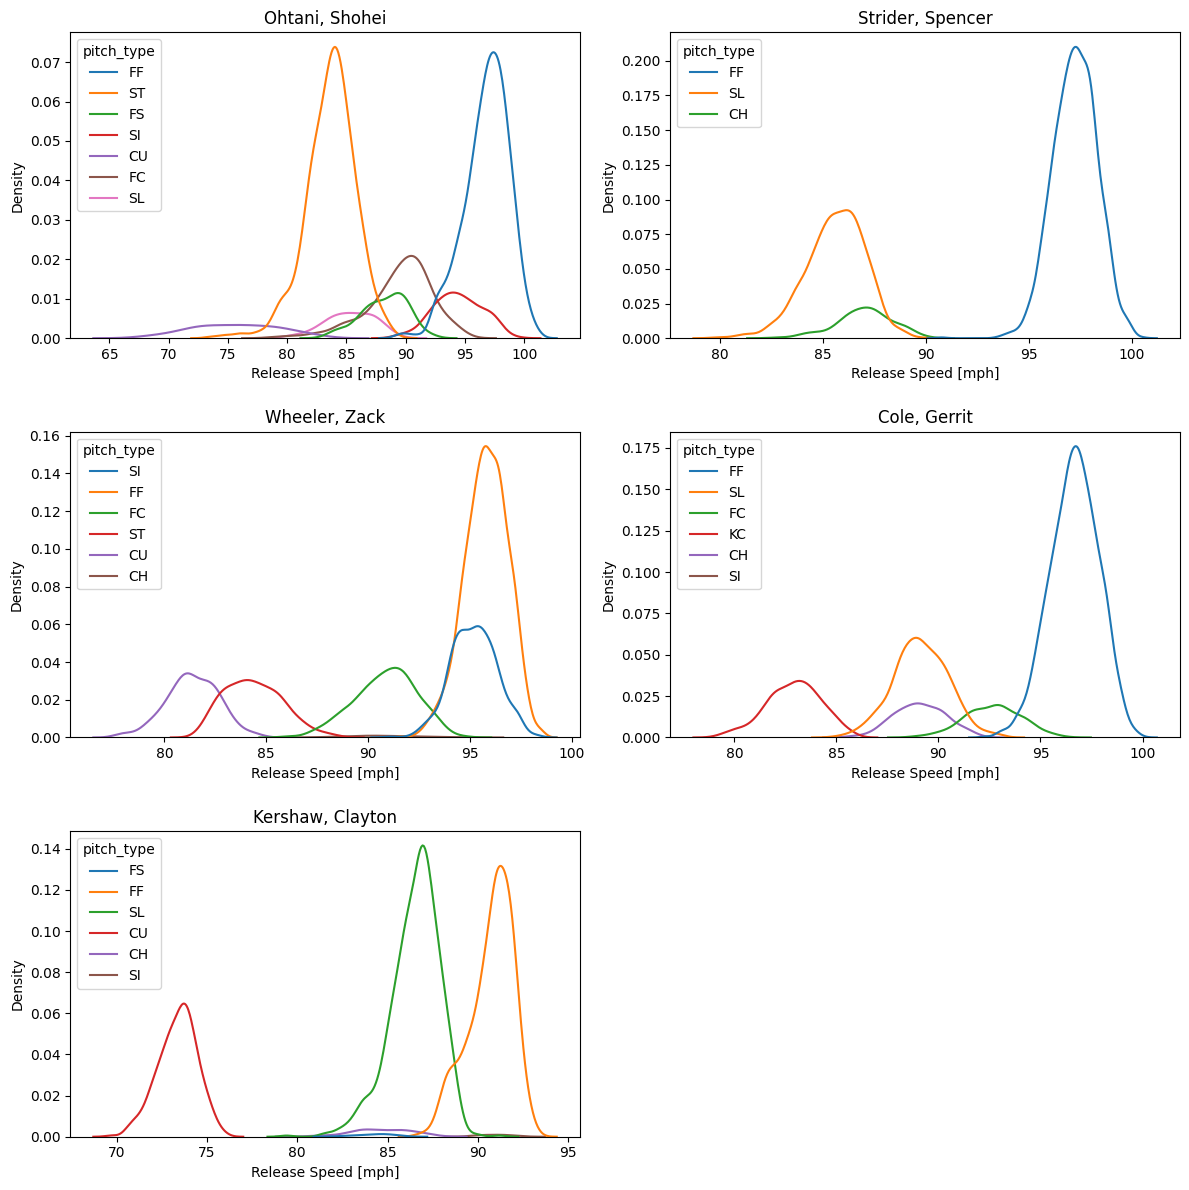

In [8]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4))
axes = axes.flatten()

for ax, pitcher in zip(axes, pitchers):
    pitcher_df = df[df['player_name'] == pitcher]
    sns.kdeplot(data=pitcher_df, x='release_speed', hue='pitch_type', ax=ax, warn_singular=False)
    ax.set_title(pitcher)
    ax.set_xlabel('Release Speed [mph]')
    ax.set_ylabel('Density')

for ax in axes[len(pitchers):]:
    ax.set_visible(False)

plt.tight_layout(h_pad=2)
plt.show()

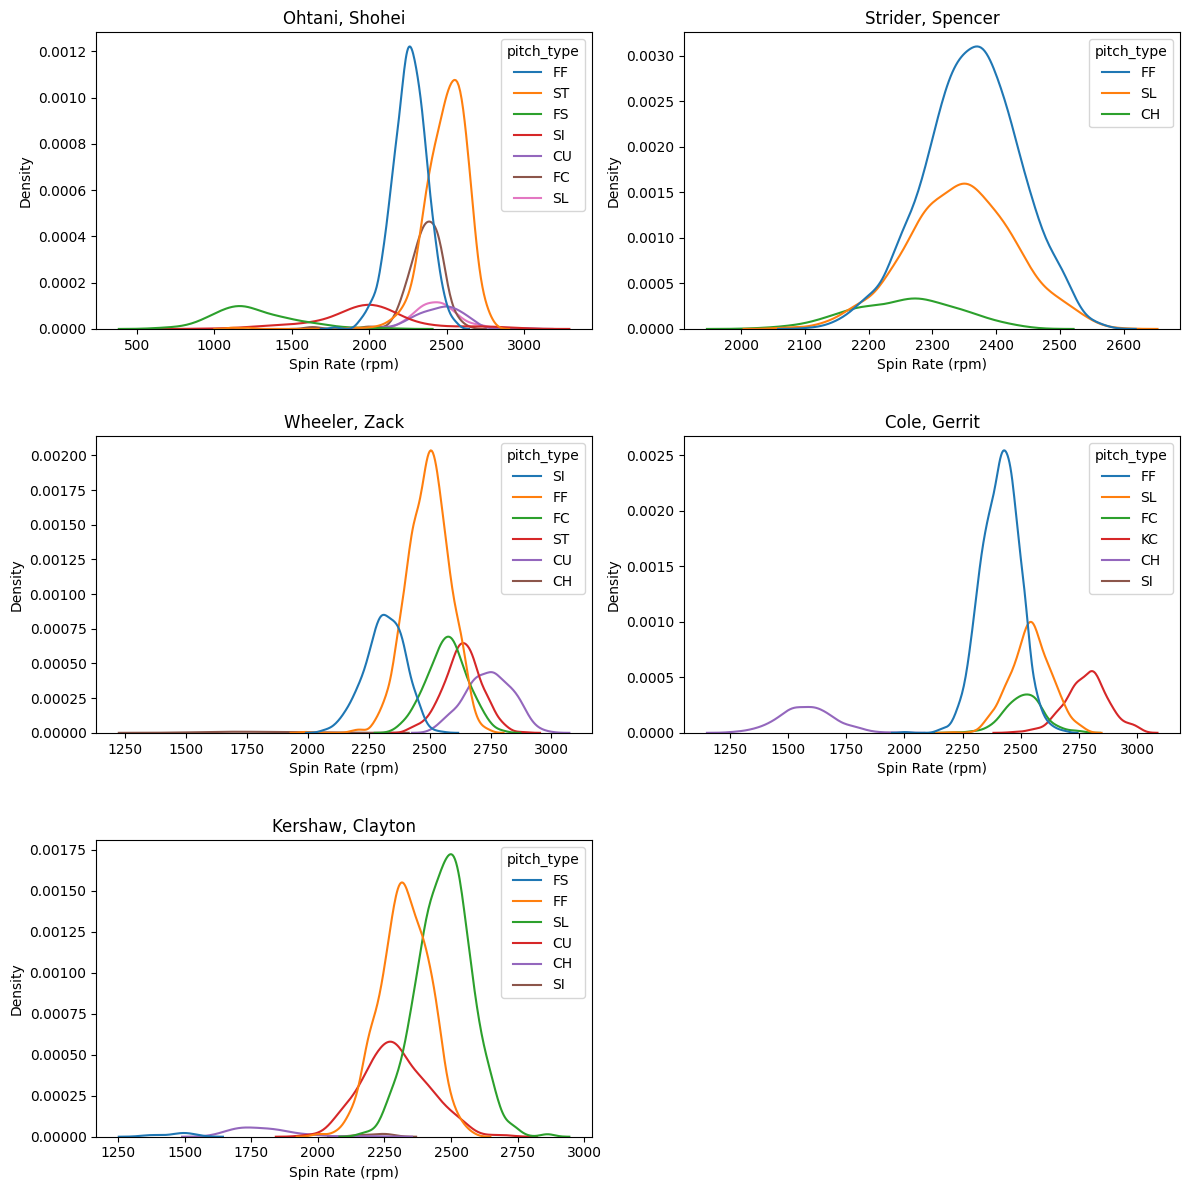

In [9]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4))
axes = axes.flatten()

for ax, pitcher in zip(axes, pitchers):
    pitcher_df = df[df['player_name'] == pitcher]
    sns.kdeplot(data=pitcher_df, x='release_spin_rate', hue='pitch_type', ax=ax, warn_singular=False)
    ax.set_title(pitcher)
    ax.set_xlabel('Spin Rate (rpm)')
    ax.set_ylabel('Density')

for ax in axes[len(pitchers):]:
    ax.set_visible(False)

plt.tight_layout(h_pad=3)
plt.show()


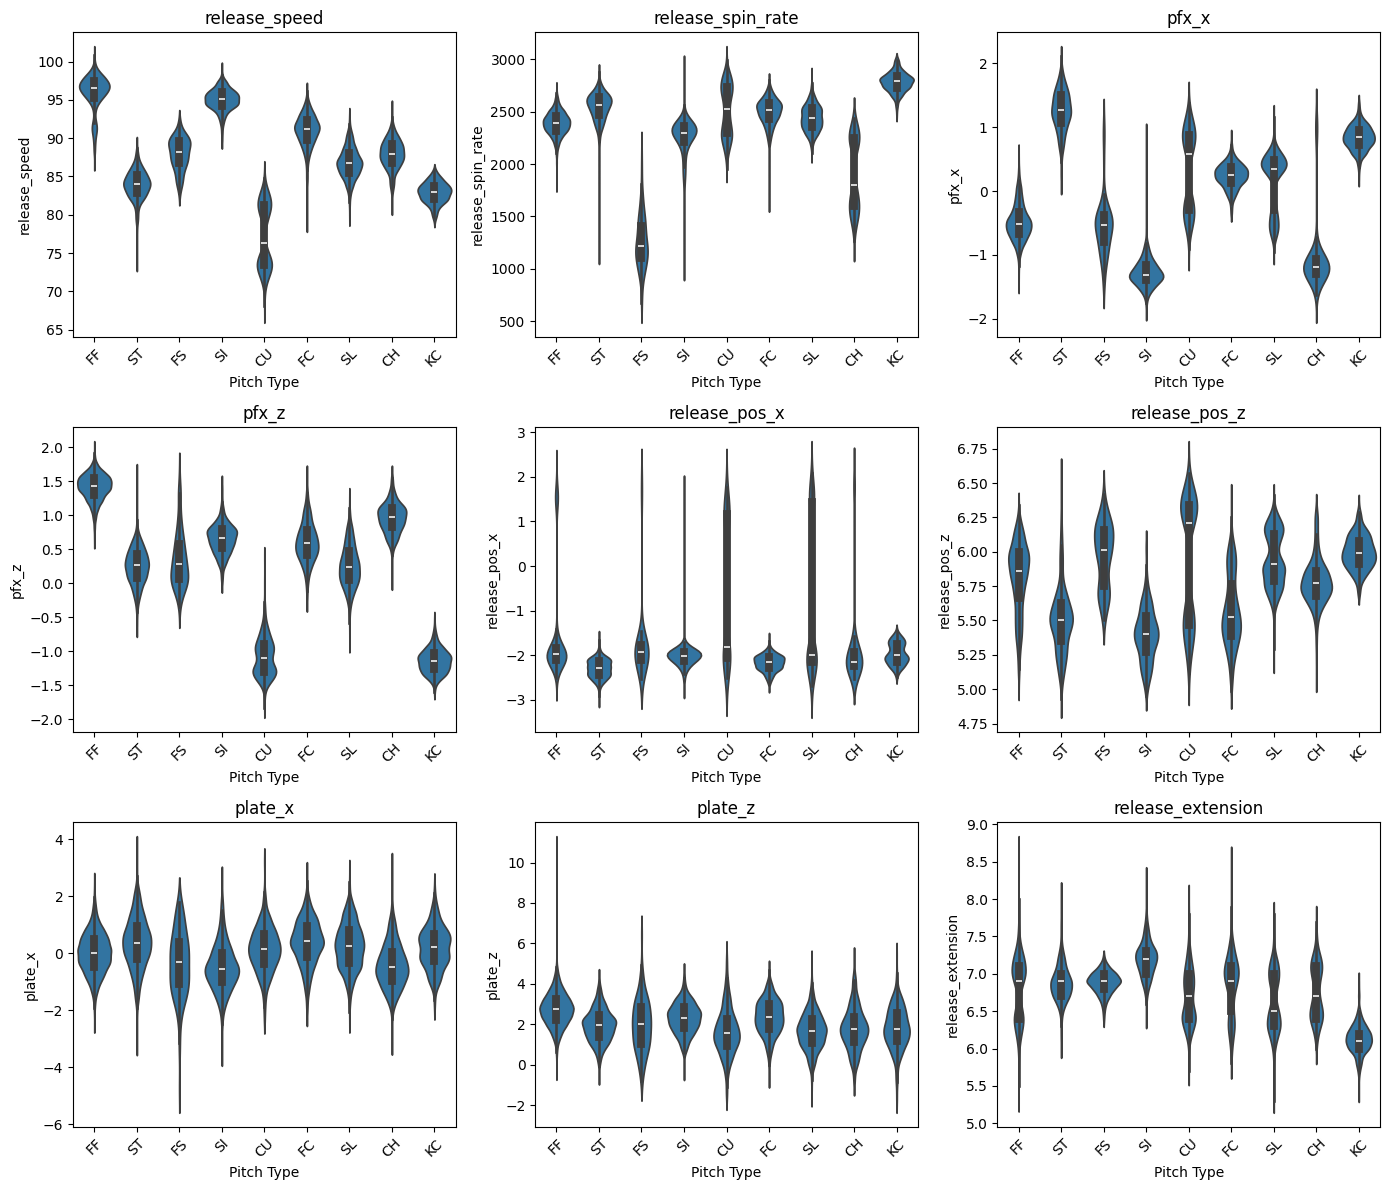

In [13]:
features = config['features']

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    sns.violinplot(data=df, x='pitch_type', y=feature, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('Pitch Type')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Some features like release_pos_x show a bimodal distribution, likely caused by pitcher handedness. Right-handed pitchers release from one side of the rubber, left-handed pitchers from the other. Without encoding handedness, the model cannot distinguish whether a given release position belongs to a lefty or a righty, making release_pos_x a weaker and potentially misleading feature. Adding p_throws gives the model the context it needs to interpret release position correctly."

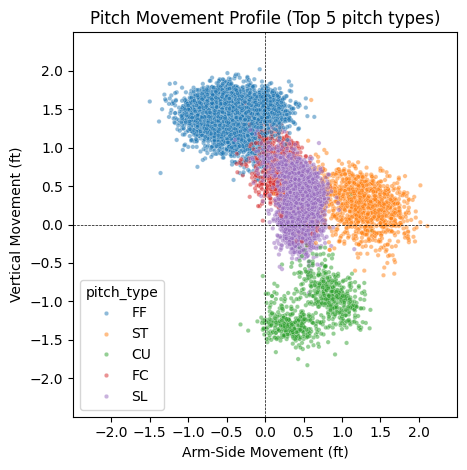

In [26]:
top_k = 5
top_pitches = df['pitch_type'].value_counts().head(top_k).index
df_top = df[df['pitch_type'].isin(top_pitches)]

sns.scatterplot(data=df_top, x='pfx_x_adjusted', y='pfx_z', hue='pitch_type', alpha=0.5, s=10)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.title(f'Pitch Movement Profile (Top {top_k} pitch types)')
plt.xlabel('Arm-Side Movement (ft)')
plt.ylabel('Vertical Movement (ft)')

lim = max(abs(df_top['pfx_x_adjusted'].max()), abs(df_top['pfx_z'].max())) + 0.2

plt.xticks(np.arange(-2, 2.5, 0.5))
plt.yticks(np.arange(-2, 2.5, 0.5))
plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)

plt.gca().set_aspect('equal')

plt.tight_layout()
plt.show()


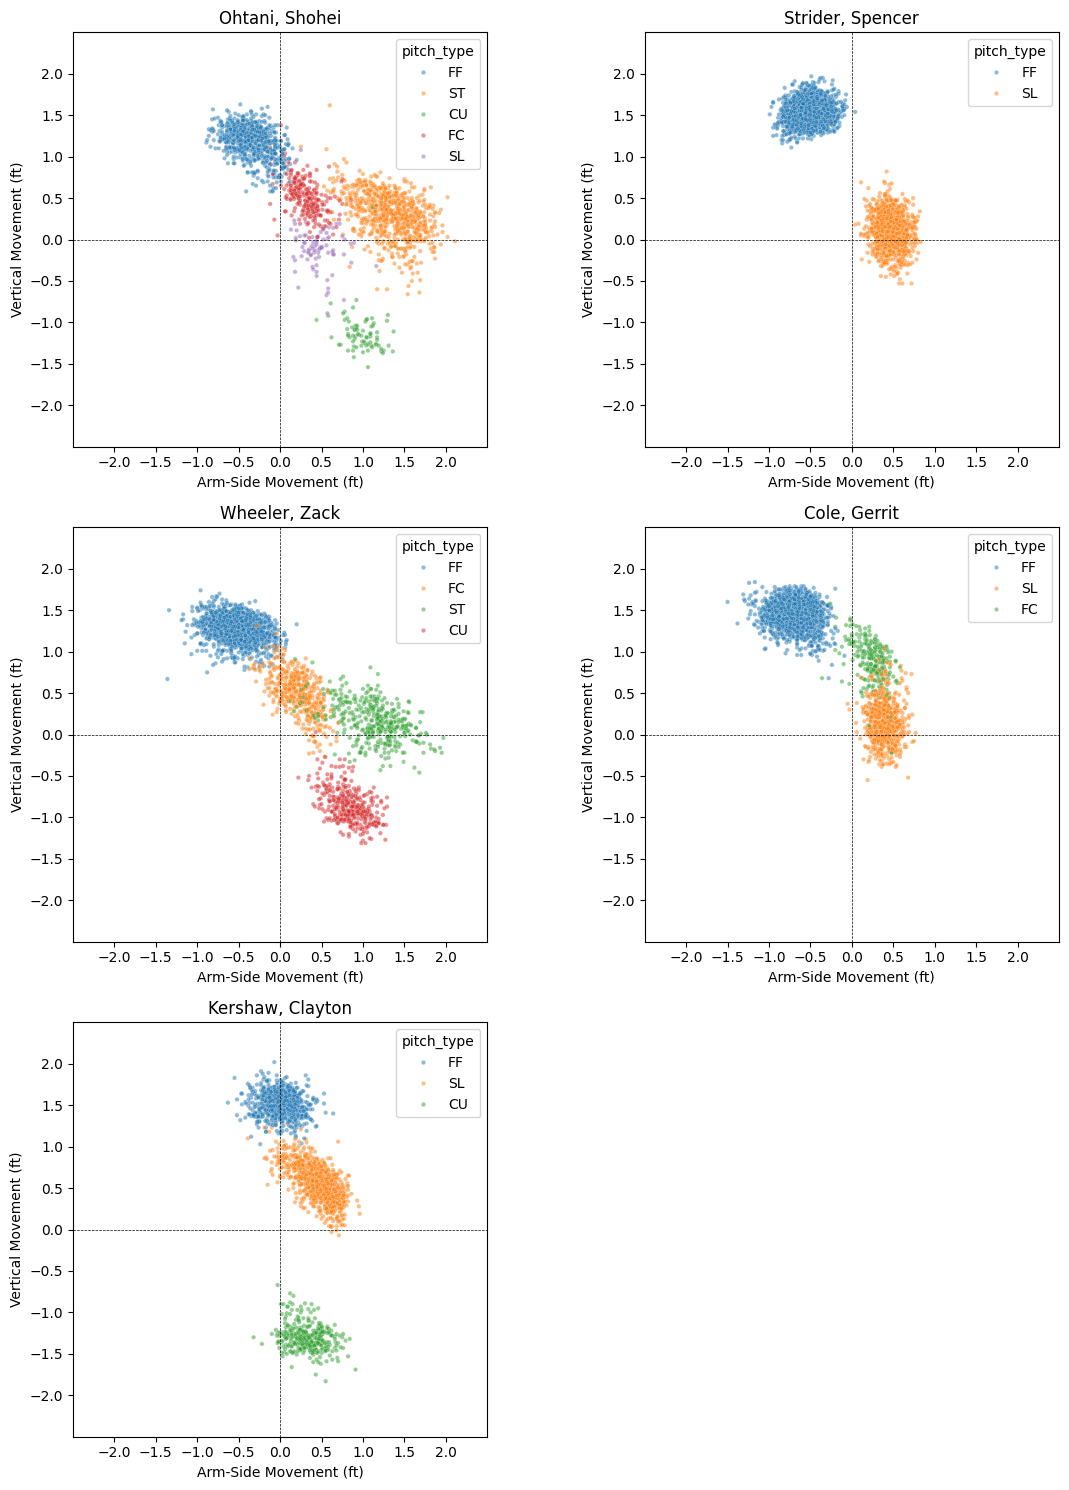

In [27]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 5))
axes = axes.flatten()

for ax, pitcher in zip(axes, pitchers):
    pitcher_df = df_top[df_top['player_name'] == pitcher]
    sns.scatterplot(data=pitcher_df, x='pfx_x_adjusted', y='pfx_z', 
                    hue='pitch_type', alpha=0.5, s=10, ax=ax)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(pitcher)
    ax.set_xlabel('Arm-Side Movement (ft)')
    ax.set_ylabel('Vertical Movement (ft)')
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_xticks(np.arange(-2, 2.5, 0.5))
    ax.set_yticks(np.arange(-2, 2.5, 0.5))
    ax.set_aspect('equal')

for ax in axes[len(pitchers):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


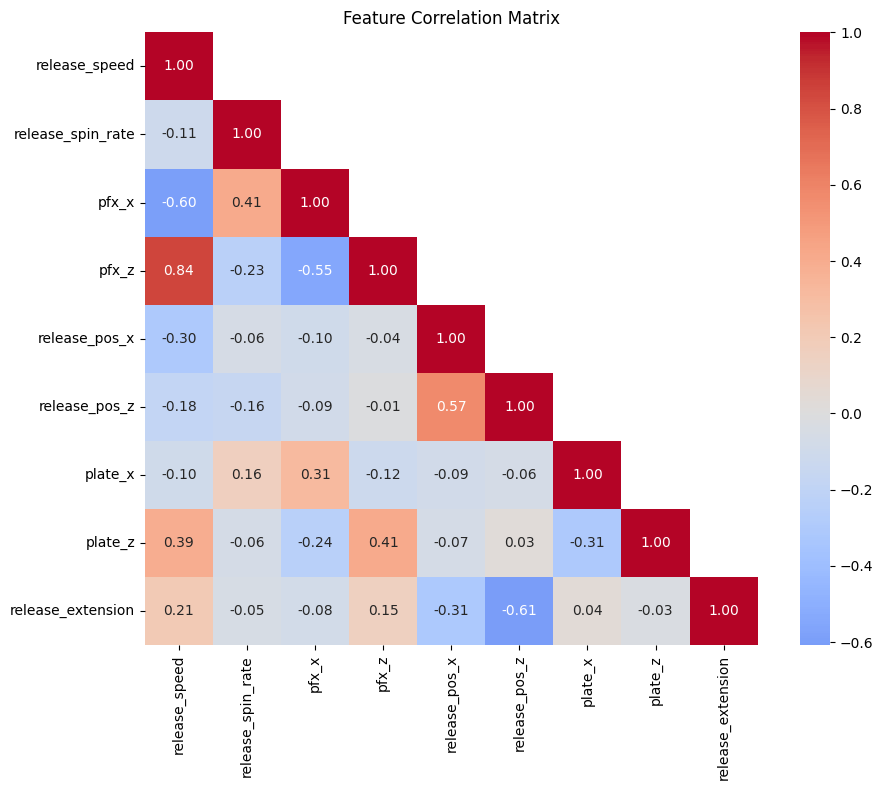

In [30]:
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, mask=mask)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


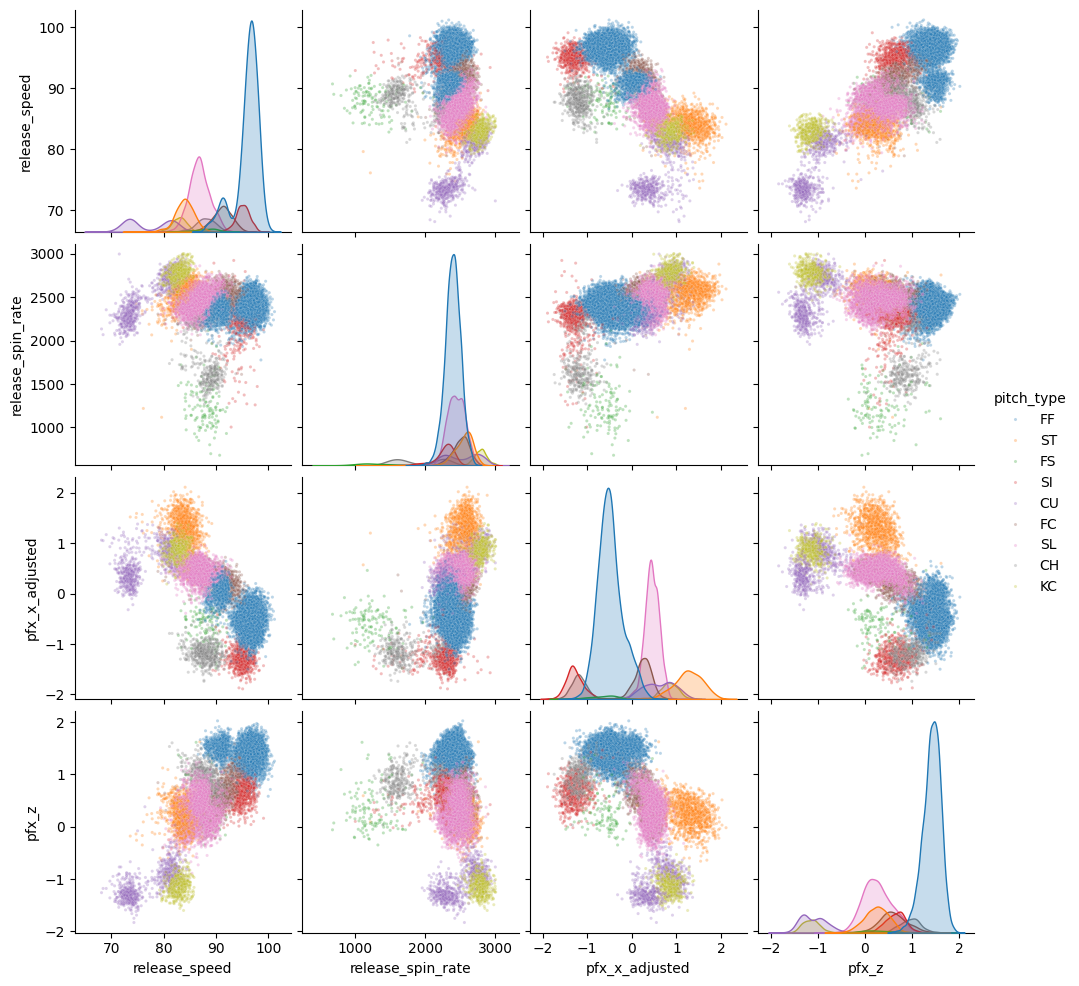

In [36]:
strong_features = ['release_speed', 'release_spin_rate', 'pfx_x_adjusted', 'pfx_z']

sns.pairplot(df, vars=strong_features, hue='pitch_type', 
             plot_kws={'alpha': 0.3, 's': 5}, diag_kind='kde')
plt.show()

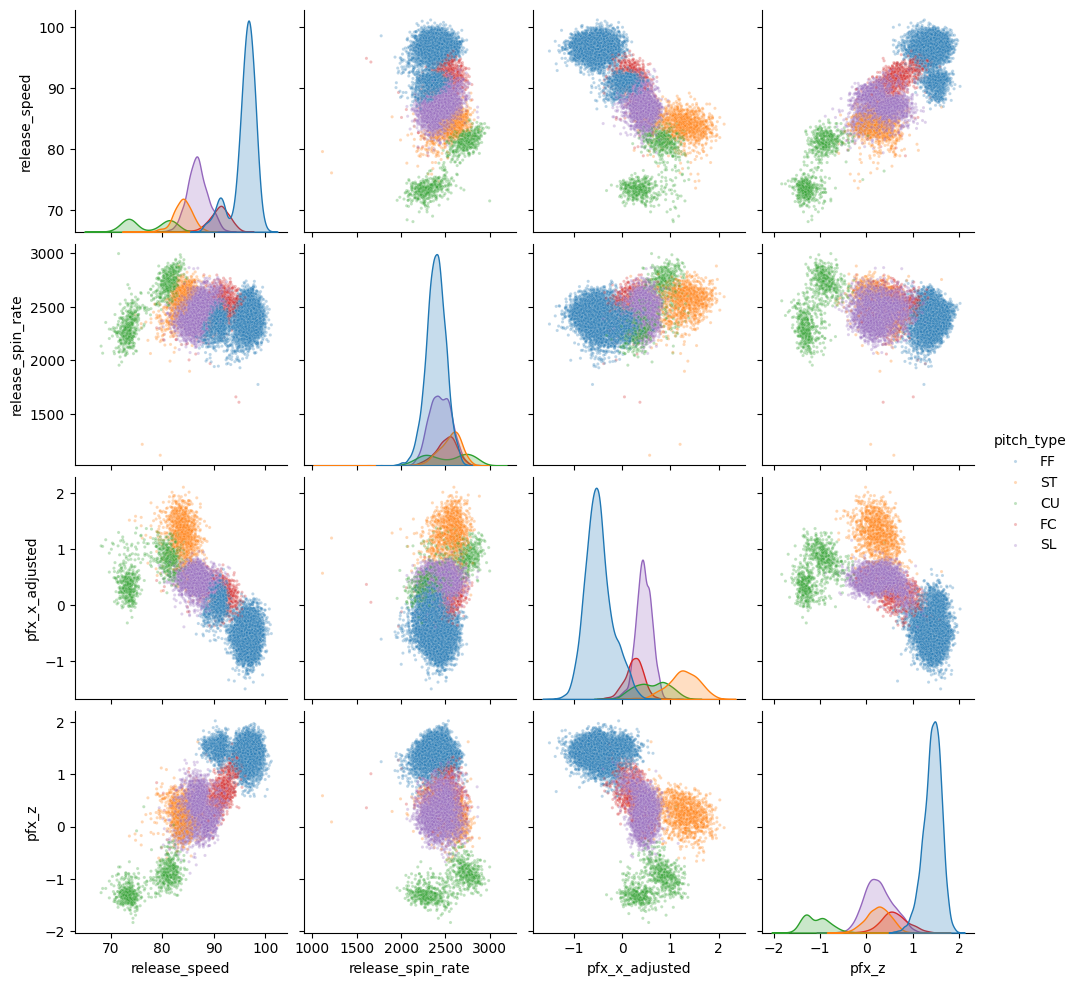

In [37]:
sns.pairplot(df_top, vars=strong_features, hue='pitch_type',
             plot_kws={'alpha': 0.3, 's': 5}, diag_kind='kde')
plt.show()
